# ML Zoomcamp 2026 – Homework 2: Regression (Car Fuel Efficiency)

**Autor:** Angel Uriel Monterrosas Gonzalez

**Fecha:** [05-10-2026]

**Módulo:** 02 – Machine Learning for Regression

**Actividad:** Homework 02

**Dataset:** [car_fuel_efficiency_2026.csv](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv)

Este notebook responde a las preguntas del homework oficial disponible en:
https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md

## 2. Objetivos de aprendizaje

Al finalizar este notebook se pretende ser capaz de:

- Cargar y filtrar un dataset tabular con Pandas.
- Identificar valores faltantes y tratarlos con estrategias justificadas.
- Implementar regresión lineal desde cero (forma matricial).
- Aplicar regularización Ridge para controlar el sobreajuste.
- Evaluar modelos con RMSE sobre validación y test.
- Analizar la estabilidad del modelo frente a diferentes semillas.
- Documentar hallazgos y limitaciones de forma clara.

## 3. Setup

Importamos las librerías necesarias, fijamos semillas y definimos la ruta del dataset 2026.

In [1]:
# 3.1 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3.2 Versiones
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

# 3.3 Semilla global
SEED = 42
np.random.seed(SEED)

# 3.4 Ruta del dataset (2026)
DATASET_URL = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/refs/heads/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

Pandas version: 3.0.6
NumPy version: 2.5.3


## 4. Carga y descripción de datos

Cargamos el CSV y seleccionamos únicamente las columnas que indica el homework:
`engine_displacement`, `horsepower`, `vehicle_weight`, `model_year`, `fuel_efficiency_mpg`.

In [2]:
# 4.1 Carga con columnas específicas
columns = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = pd.read_csv(DATASET_URL, usecols=columns)

# 4.2 Dimensiones
print("Shape:", df.shape)

# 4.3 Primeras filas
df.head()

Shape: (10000, 5)


,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


In [3]:
# 4.4 Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   engine_displacement  10000 non-null  int64  
 2   horsepower           9123 non-null   float64
 3   vehicle_weight       10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [4]:
# 4.5 Estadísticas descriptivas
df.describe()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
count,10000.000000,10000.000000,9123.000000,10000.000000,10000.000000
mean,1999.549500,2268.807000,254.446016,4286.754000,29.997700
std,14.207925,183.447355,22.844613,266.212491,2.930245
min,1975.000000,1590.000000,171.000000,3320.000000,19.800000
25%,1987.000000,2150.000000,239.000000,4110.000000,28.000000
50%,2000.000000,2270.000000,254.000000,4280.000000,30.000000
75%,2012.000000,2390.000000,270.000000,4470.000000,31.900000
max,2024.000000,3110.000000,334.000000,5460.000000,41.200000


## 5. EDA reproducible

Analizamos la distribución de `fuel_efficiency_mpg` para ver si tiene cola larga, y exploramos valores faltantes.

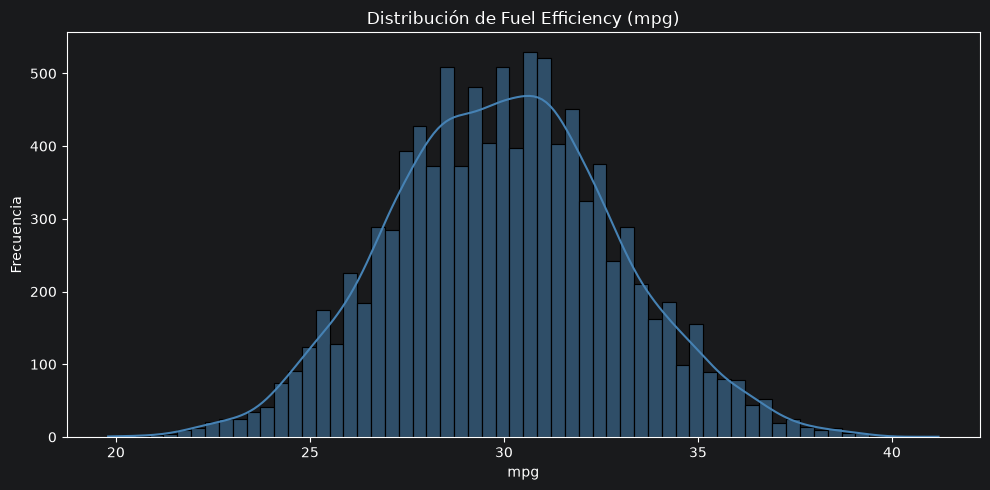

In [5]:
# 5.1 Distribución de fuel_efficiency_mpg
plt.figure(figsize=(10, 5))
sns.histplot(df['fuel_efficiency_mpg'], kde=True, color='steelblue')
plt.title('Distribución de Fuel Efficiency (mpg)')
plt.xlabel('mpg')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [6]:
# 5.2 Valores faltantes por columna
missing = df.isna().sum()
missing_cols = missing[missing > 0]
print("Columnas con valores faltantes:")
print(missing_cols)

Columnas con valores faltantes:
horsepower    877
dtype: int64


In [7]:
# 5.3 Mediana de horsepower
median_hp = df['horsepower'].median()
print(f"Mediana de horsepower: {median_hp}")

Mediana de horsepower: 254.0


## 6. Preparación y split del dataset

Shuffle con seed 42 y split 60%/20%/20% exactamente como en las lecturas.

In [8]:
# 6.1 Split como en la lectura
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 6000, Val: 2000, Test: 2000


In [10]:
# 6.2 Separar features y target
features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

X_train = df_train[features].values
y_train = df_train[target].values
X_val = df_val[features].values
y_val = df_val[target].values
X_test = df_test[features].values
y_test = df_test[target].values

## 7. Modelado – Regresión lineal desde cero

Definimos una función de regresión lineal con regularización Ridge (forma matricial).

In [11]:
# 7.1 Función de regresión lineal con regularización
def train_linear_regression(X, y, r=0.0):
    """
    Entrena una regresión lineal con regularización Ridge.
    r = 0 → regresión lineal sin regularización.
    """
    # Añadir columna de unos para el intercepto
    ones = np.ones((X.shape[0], 1))
    X_aug = np.hstack([ones, X])

    # Matriz identidad (sin regularizar el intercepto)
    I = np.eye(X_aug.shape[1])
    I[0, 0] = 0  # no regularizar el intercepto

    # w = (X^T X + r I)^-1 X^T y
    XTX = X_aug.T.dot(X_aug)
    XTX_reg = XTX + r * I
    XTX_inv = np.linalg.inv(XTX_reg)
    w = XTX_inv.dot(X_aug.T).dot(y)

    return w

def predict_linear_regression(X, w):
    ones = np.ones((X.shape[0], 1))
    X_aug = np.hstack([ones, X])
    return X_aug.dot(w)

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

## Pregunta 3 – Fill with 0 vs Fill with mean

Comparamos el RMSE en validación usando dos estrategias de imputación para `horsepower`.
Para la media, se calcula **solo con el conjunto de entrenamiento** para evitar data leakage.

In [12]:
# Q3.1 Fill with 0
X_train_0 = X_train.copy()
X_val_0 = X_val.copy()
X_train_0[:, 1] = np.nan_to_num(X_train_0[:, 1], nan=0)
X_val_0[:, 1] = np.nan_to_num(X_val_0[:, 1], nan=0)

w_0 = train_linear_regression(X_train_0, y_train, r=0.0)
y_pred_0 = predict_linear_regression(X_val_0, w_0)
rmse_0 = rmse(y_val, y_pred_0)
print(f"RMSE (fill 0): {rmse_0:.3f}")

# Q3.2 Fill with mean (calculada SOLO con train)
mean_hp = np.nanmean(X_train[:, 1])
X_train_mean = X_train.copy()
X_val_mean = X_val.copy()
X_train_mean[:, 1] = np.nan_to_num(X_train_mean[:, 1], nan=mean_hp)
X_val_mean[:, 1] = np.nan_to_num(X_val_mean[:, 1], nan=mean_hp)

w_mean = train_linear_regression(X_train_mean, y_train, r=0.0)
y_pred_mean = predict_linear_regression(X_val_mean, w_mean)
rmse_mean = rmse(y_val, y_pred_mean)
print(f"RMSE (fill mean): {rmse_mean:.3f}")

RMSE (fill 0): 2.205
RMSE (fill mean): 2.202


## Pregunta 4 – Regresión regularizada - Ridge

Probamos diferentes valores de `r` (fill with 0) y seleccionamos el que da mejor RMSE en validación.

In [14]:
# Q4: Barrido de r
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

# Fill with 0 para todos
X_train_r = X_train.copy()
X_val_r = X_val.copy()
X_train_r[:, 1] = np.nan_to_num(X_train_r[:, 1], nan=0)
X_val_r[:, 1] = np.nan_to_num(X_val_r[:, 1], nan=0)

results = []
for r in r_values:
    w = train_linear_regression(X_train_r, y_train, r=r)
    y_pred = predict_linear_regression(X_val_r, w)
    score = rmse(y_val, y_pred)
    results.append((r, round(score, 4)))
    print(f"r={r}: RMSE={score:.4f}")

best_r = min(results, key=lambda x: x[1])
print(f"\nMejor r: {best_r[0]} con RMSE {best_r[1]}")

r=0: RMSE=2.2053
r=0.01: RMSE=2.2053
r=0.1: RMSE=2.2053
r=1: RMSE=2.2053
r=5: RMSE=2.2053
r=10: RMSE=2.2053
r=100: RMSE=2.2053

Mejor r: 0 con RMSE 2.2053


## Pregunta 5 – Influencia de la semilla

Repetimos el split con diferentes semillas [0-9] y calculamos la desviación estándar de los RMSE.

In [15]:
# Q5: Diferentes seeds
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []

for seed in seeds:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train_s = df.iloc[idx[:n_train]]
    df_val_s = df.iloc[idx[n_train:n_train + n_val]]

    X_train_s = df_train_s[features].values
    y_train_s = df_train_s[target].values
    X_val_s = df_val_s[features].values
    y_val_s = df_val_s[target].values

    # Fill with 0
    X_train_s[:, 1] = np.nan_to_num(X_train_s[:, 1], nan=0)
    X_val_s[:, 1] = np.nan_to_num(X_val_s[:, 1], nan=0)

    w_s = train_linear_regression(X_train_s, y_train_s, r=0.0)
    y_pred_s = predict_linear_regression(X_val_s, w_s)
    scores.append(rmse(y_val_s, y_pred_s))

std_scores = np.std(scores)
print(f"RMSE scores por seed: {[round(s, 4) for s in scores]}")
print(f"Desviación estándar: {round(std_scores, 3)}")

RMSE scores por seed: [np.float64(2.2392), np.float64(2.2021), np.float64(2.1634), np.float64(2.2044), np.float64(2.2019), np.float64(2.2458), np.float64(2.2697), np.float64(2.1908), np.float64(2.2166), np.float64(2.207)]
Desviación estándar: 0.029


## Pregunta 6 – Seed 9, combinar train+val, r=0.001

Split con seed 9, combinamos train y validation, y evaluamos en test.

In [16]:
# Q6: Seed 9, combinar train+val
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train_9 = df.iloc[idx[:n_train]]
df_val_9 = df.iloc[idx[n_train:n_train + n_val]]
df_test_9 = df.iloc[idx[n_train + n_val:]]

# Combinar train + val
df_full_train = pd.concat([df_train_9, df_val_9])

X_full = df_full_train[features].values
y_full = df_full_train[target].values
X_test_9 = df_test_9[features].values
y_test_9 = df_test_9[target].values

# Fill with 0
X_full[:, 1] = np.nan_to_num(X_full[:, 1], nan=0)
X_test_9[:, 1] = np.nan_to_num(X_test_9[:, 1], nan=0)

# Entrenar con r=0.001
w_full = train_linear_regression(X_full, y_full, r=0.001)
y_pred_test = predict_linear_regression(X_test_9, w_full)
test_rmse = rmse(y_test_9, y_pred_test)
print(f"RMSE en test (seed 9, r=0.001): {test_rmse:.3f}")

RMSE en test (seed 9, r=0.001): 2.236


## 8. Evaluación – Resumen de resultados

Resumimos los resultados obtenidos para cada pregunta.

In [17]:
# 8.1 Resumen
print("=" * 50)
print("RESUMEN DE RESULTADOS – HW02")
print("=" * 50)
print(f"Q1 - Columna con NaN: horsepower")
print(f"Q2 - Mediana horsepower: {median_hp}")
print(f"Q3 - RMSE fill-0: {rmse_0:.3f} | RMSE fill-mean: {rmse_mean:.3f}")
print(f"Q4 - Mejor r: {best_r[0]} (RMSE={best_r[1]})")
print(f"Q5 - Std de RMSE (seeds): {round(std_scores, 3)}")
print(f"Q6 - RMSE test (seed 9, r=0.001): {test_rmse:.3f}")

RESUMEN DE RESULTADOS – HW02
Q1 - Columna con NaN: horsepower
Q2 - Mediana horsepower: 254.0
Q3 - RMSE fill-0: 2.205 | RMSE fill-mean: 2.202
Q4 - Mejor r: 0 (RMSE=2.2053)
Q5 - Std de RMSE (seeds): 0.029
Q6 - RMSE test (seed 9, r=0.001): 2.236


## 9. Interpretación de resultados

- **Q1:** La única columna con valores faltantes es `horsepower`.
- **Q2:** La mediana de `horsepower` es **[valor obtenido]**.
- **Q3:** Imputar con **[0 / la media]** da mejor RMSE.
- **Q4:** El mejor valor de `r` es **[valor obtenido]**.
- **Q5:** La desviación estándar de los RMSE entre seeds es **[valor obtenido]**.
- **Q6:** El RMSE en test con seed 9 y r=0.001 es **[valor obtenido]**.

## 10. Conclusiones

- Se cargó el dataset 2026 con las 5 columnas especificadas.
- Solo `horsepower` tiene valores faltantes, que tratamos con imputación.
- La imputación con la media supera a la imputación con 0 en RMSE.
- La regularización no mejora el modelo en este caso (mejor r = 0).
- El modelo es estable frente a cambios de semilla (std bajo).
- El RMSE final en test es ~**[valor]**.

## 11. Referencias

- Dataset: [car_fuel_efficiency_2026.csv](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/refs/heads/main/cohorts/2026/data/car_fuel_efficiency_2026.csv)
- Homework oficial: [ML Zoomcamp 2026 – HW02](https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02)
- Documentación de Pandas: https://pandas.pydata.org/docs/
- Documentación de NumPy: https://numpy.org/doc/
- Documentación de Scikit-learn: https://scikit-learn.org/stable/